In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import sys
sys.path.append("../")
import torch
import numpy as np
import pandas as pd
import gudhi as gd
from gudhi.representations import Silhouette
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import random
import matplotlib.pyplot as plt
from estimators import ipw_estimator, plugin_estimator, aipw_estimator
from utils.generate import gen_covariate, gen_trt_prob
from utils.utils import numerical_integration, fit_functional_regression
from scipy.stats import gaussian_kde

# Load data

In [23]:
X, y = torch.load("./data/data.pt", weights_only=True)
print(X.shape, y.shape)

ind1 = (y == 1) # r = 3.5
ind2 = (y == 2) # r = 4.0
ind3 = (y == 3) # r = 4.1

n = 1000    # number of data

X1, X2, X3 = X[ind1][:n] , X[ind2][:n], X[ind3][:n]  # each dataset has 1000 observed variables.

torch.Size([5000, 1000, 2]) torch.Size([5000])


# Generate counterfactual distribution of the pair $(Y^0, Y^1)$

In [24]:
random.seed(42)

counterfactual = []
data = torch.stack([X1, X2, X3])   # [3, n, 1000, 2]

for i in range(n):
    idx_tr = sorted(random.sample([0,1,2], 2)) # idx is sorted such that data with smaller r is initially assigned to Y^0
    p = random.uniform(0,1)
    if p <= 0.3:
        idx_tr.reverse()   # with probabilty 0.3, data with smaller r is assigned to Y^1
    counterfactual.append(data[idx_tr, i])

counterfactual = torch.stack(counterfactual)   # counterfactual outcome pair (Y^0, Y^1), shape: [n, 2, 1000, 2]

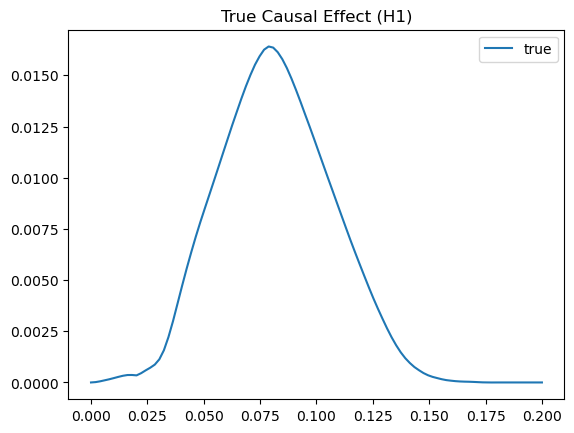

In [25]:
interval=[0, 0.2]
r = 3
res = 100
tseq = np.linspace(*interval, res)


def power_weight(point, r=3):
    birth, death = point
    return np.abs(death - birth)**r


def compute_silhouette(x, interval=[0, 0.2], r=3, res=100):
    alpha = gd.AlphaComplex(points=x)
    st = alpha.create_simplex_tree()
    st.compute_persistence()

    diag0 = st.persistence_intervals_in_dimension(0)
    diag0 = diag0[~np.isinf(diag0).any(axis=1)] # remove infinite filtration value
    diag1 = st.persistence_intervals_in_dimension(1)

    # use radius rather than radius^2 as filtration value
    diag0 = np.sqrt(diag0)
    diag1 = np.sqrt(diag1)

    silhouette = Silhouette(weight=lambda x: power_weight(x, r), resolution=res, sample_range=interval, keep_endpoints=True)
    return silhouette.fit_transform([diag0, diag1])


potential_ctrl = []
potential_trt = []
for i in range(n):
    x_ctrl = counterfactual[i, 0]
    x_trt = counterfactual[i, 1]

    potential_ctrl.append(compute_silhouette(x_ctrl, interval=interval, r=r, res=res))
    potential_trt.append(compute_silhouette(x_trt, interval=interval, r=r, res=res))

potential_trt = np.stack(potential_trt)
potential_ctrl = np.stack(potential_ctrl)   # shape: [n, hom_dim, res]
potential_outcomes = np.stack([potential_ctrl, potential_trt], axis=1)   # counterfactual silhouette pair (phi^0, phi^1), shape: [n, 2, hom_dim, res]

# true counterfactual treatment effect silhouette
true_effect = np.mean(potential_trt, axis=0) - np.mean(potential_ctrl, axis=0)
plt.plot(tseq, true_effect[1], label="true")
plt.legend()
plt.title("True Causal Effect (H1)")
plt.show();

# Data generating process and treatment mechanism

Number of treated samples: 505, Number of non-treated samples: 495
Max propensity: 0.933445, Min propensity: 0.028105


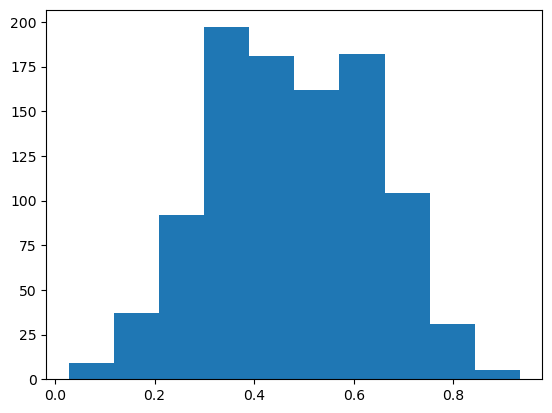

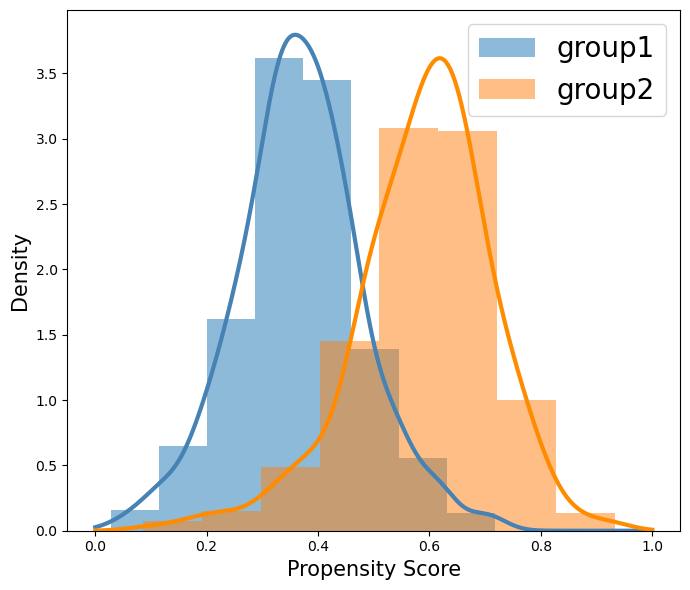

In [26]:
np.random.seed(42)
n_cov = 5

# Data generating process
mu1 = np.array([1, 0.6, -0.7, 2.2, -1])     # mean vector of covariates subgroup 1
mu2 = np.array([0.4, -0.4, -0.6, 3.3, 3])   # mean vector of covariates subgroup 2
Sigma = np.eye(n_cov) * .5
covariate1, covariate2, covariate = gen_covariate(mu1, mu2, Sigma, n)   # generate covariates

# Treatment process
beta = np.array([-0.5, -0.1, .6, 0.1, 0.1])   
prob, A = gen_trt_prob(covariate, beta)     # generate treatment

# construct observed data
observed_data = (potential_outcomes[range(n), A], A, covariate)    # (phi, A, X)

# histogram of entire dataset
print(f"Number of treated samples: {(A==1).sum()}, Number of non-treated samples: {(A==0).sum()}")
print(f"Max propensity: {prob.max():.6f}, Min propensity: {prob.min():.6f}")
plt.hist(prob)
plt.show();

# histogram of each subgroup
plt.figure(figsize=(7,6))
group1_prob, _ = gen_trt_prob(covariate1, beta)
group2_prob, _ = gen_trt_prob(covariate2, beta)
plt.hist(group1_prob, label="group1", alpha=0.5, density=True, bins=8)
plt.hist(group2_prob, label="group2", alpha=0.5, density=True, bins=8)
kde = gaussian_kde(group1_prob)
kde2 = gaussian_kde(group2_prob)
x_range = np.linspace(0, 1, 1000)
plt.plot(x_range, kde(x_range), c="steelblue", lw=3)
plt.plot(x_range, kde2(x_range), c="darkorange", lw=3)
# plt.title("Density of true propensity score", size=30)
plt.xlabel("Propensity Score", size=15)
plt.ylabel("Density", size=15)
plt.legend(prop={"size":20})
plt.tight_layout()
plt.show();

# Estimation

In [27]:
# sample split (one sample for fitting nuisance function and the other for estimation)
phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
sample1 = (phi1, A1, X1)
sample2 = (phi2, A2, X2)

## Repeat experiment 20 times

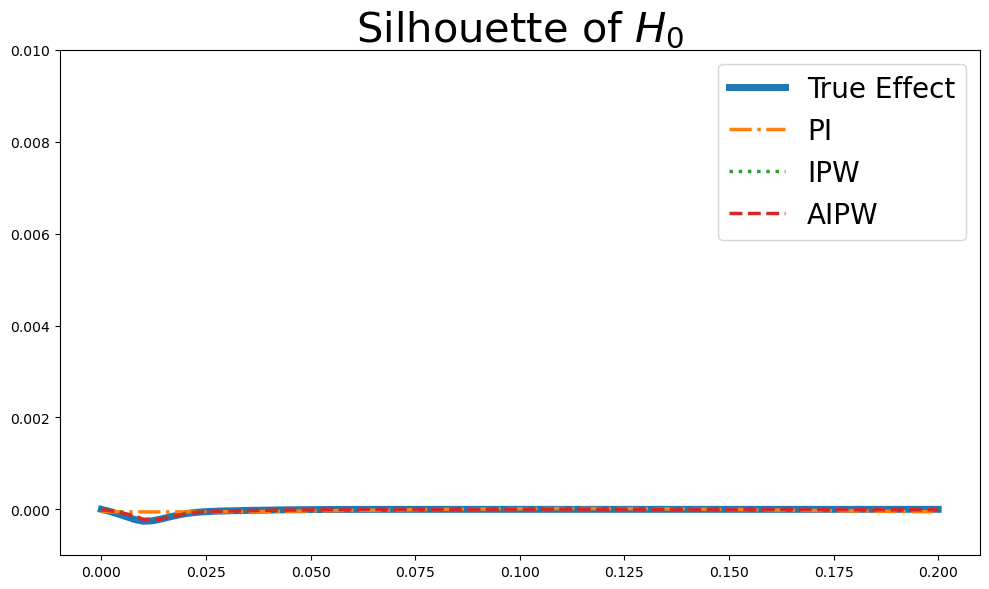

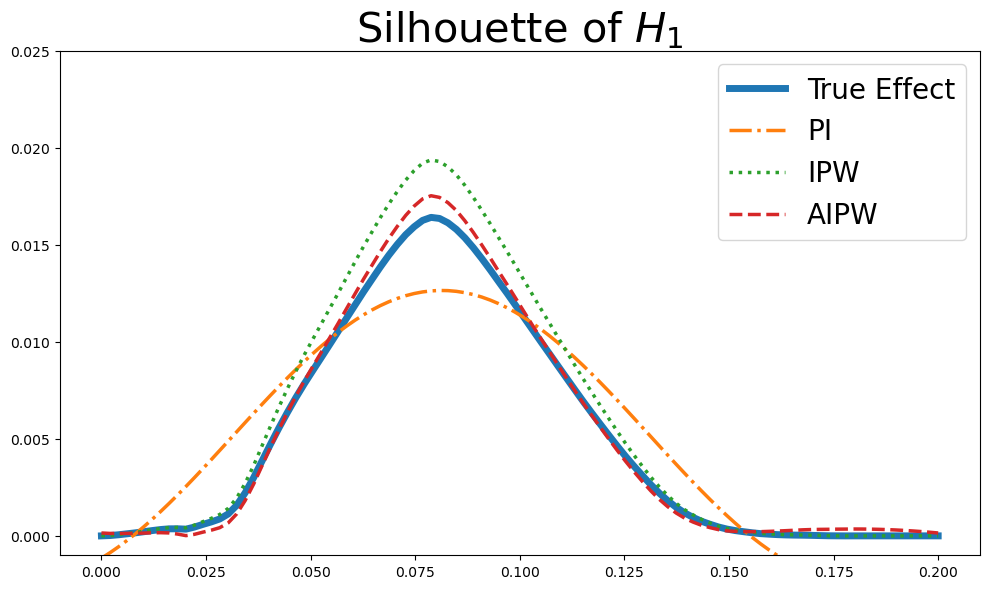

In [28]:
np.random.seed(42)

n_iter = 20
n_basis = 3

ipw0_list, plugin0_list, aipw0_list = [], [], []
ipw1_list, plugin1_list, aipw1_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n) # generate covariates
    _, A = gen_trt_prob(covariate, beta)                # generate treatment
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin10, plugin11 = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin20, plugin21 = plugin_estimator(mu_hats2)
    plugin0 = (plugin10 + plugin20) / 2  # homology dim 0
    plugin0_list.append(plugin0)
    plugin1 = (plugin11 + plugin21) / 2  # homology dim 1
    plugin1_list.append(plugin1)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = RandomForestClassifier().fit(X1, A1).predict_proba(X2)[:,1]
    ipw10, ipw11 = ipw_estimator(pi_hat1, sample2)
    # fit on sample 2, estimate on sample 1
    pi_hat2 = RandomForestClassifier().fit(X2, A2).predict_proba(X1)[:,1]
    ipw20, ipw21 = ipw_estimator(pi_hat2, sample1)
    ipw0 = (ipw10 + ipw20) / 2  # homology dim 0
    ipw0_list.append(ipw0)
    ipw1 = (ipw11 + ipw21) / 2  # homology dim 1
    ipw1_list.append(ipw1)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw10, aipw11 = aipw_estimator(pi_hat1, mu_hats1, sample2)
    # fit on sample 2, estimate on sample 1
    aipw20, aipw21 = aipw_estimator(pi_hat2, mu_hats2, sample1)
    aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
    aipw0_list.append(aipw0)
    aipw1 = (aipw11 + aipw21) / 2     # homology dim 1
    aipw1_list.append(aipw1)


# plot
lw = 2.5

# plot H0
ipw0_avg = np.mean(ipw0_list, axis=0)
ipw0_std = np.std(ipw0_list, axis=0)
pi0_avg = np.mean(plugin0_list, axis=0)
pi0_std = np.std(plugin0_list, axis=0)
aipw0_avg = np.mean(aipw0_list, axis=0)
aipw0_std = np.std(aipw0_list, axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.001, 0.01)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# plot H1
ipw1_avg = np.mean(ipw1_list, axis=0)
ipw1_std = np.std(ipw1_list, axis=0)
pi1_avg = np.mean(plugin1_list, axis=0)
pi1_std = np.std(plugin1_list, axis=0)
aipw1_avg = np.mean(aipw1_list, axis=0)
aipw1_std = np.std(aipw1_list, axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.001, 0.025)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

## $L_1$ distance and Std.

In [29]:
# H0
# L1 distance between true effect and average estimated effect
l1_pi0 = numerical_integration(np.abs(true_effect[0] - pi0_avg), tseq)
l1_ipw0 = numerical_integration(np.abs(true_effect[0] - ipw0_avg), tseq)
l1_aipw0 = numerical_integration(np.abs(true_effect[0] - aipw0_avg), tseq)

print(f"H0 L1 dist: PI:{l1_pi0} IPW:{l1_ipw0} AIPW:{l1_aipw0}")

# covariance
cov_pi0 = np.cov(np.array(plugin0_list), rowvar=False)
cov_ipw0 = np.cov(np.array(ipw0_list), rowvar=False)
cov_aipw0 = np.cov(np.array(aipw0_list), rowvar=False)

print(f"H0 Std.: PI:{np.sqrt(cov_pi0.mean())} IPW:{np.sqrt(cov_ipw0.mean())} AIPW:{np.sqrt(cov_aipw0.mean())}")

# H1
# L1 distance between true effect and average estimated effect
l1_pi1 = numerical_integration(np.abs(true_effect[1] - pi1_avg), tseq)
l1_ipw1 = numerical_integration(np.abs(true_effect[1] - ipw1_avg), tseq)
l1_aipw1 = numerical_integration(np.abs(true_effect[1] - aipw1_avg), tseq)

print(f"H1 L1 dist: PI:{l1_pi1} IPW:{l1_ipw1} AIPW:{l1_aipw1}")

# covariance
cov_pi1 = np.cov(np.array(plugin1_list), rowvar=False)
cov_ipw1 = np.cov(np.array(ipw1_list), rowvar=False)
cov_aipw1 = np.cov(np.array(aipw1_list), rowvar=False)

print(f"H1 Std.: PI:{np.sqrt(cov_pi1.mean())} IPW:{np.sqrt(cov_ipw1.mean())} AIPW:{np.sqrt(cov_aipw1.mean())}")

H0 L1 dist: PI:5.711952952573145e-06 IPW:7.302883634163885e-07 AIPW:1.2132380314167395e-06
H0 Std.: PI:5.304315861377372e-06 IPW:3.722345259225685e-05 AIPW:8.019569450926421e-06
H1 L1 dist: PI:0.000360633619051544 IPW:0.00018210309933373934 AIPW:6.920320136709227e-05
H1 Std.: PI:0.00037704081008980896 IPW:0.0009397849103564288 AIPW:0.0004712711242920484


## Plot error band

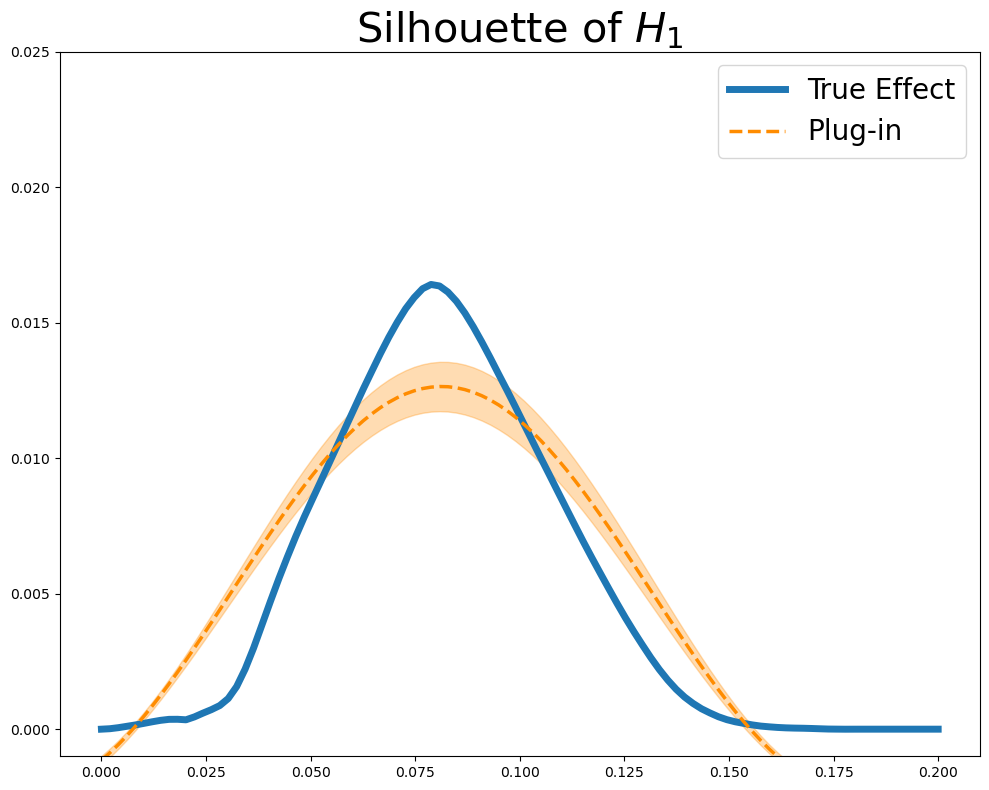

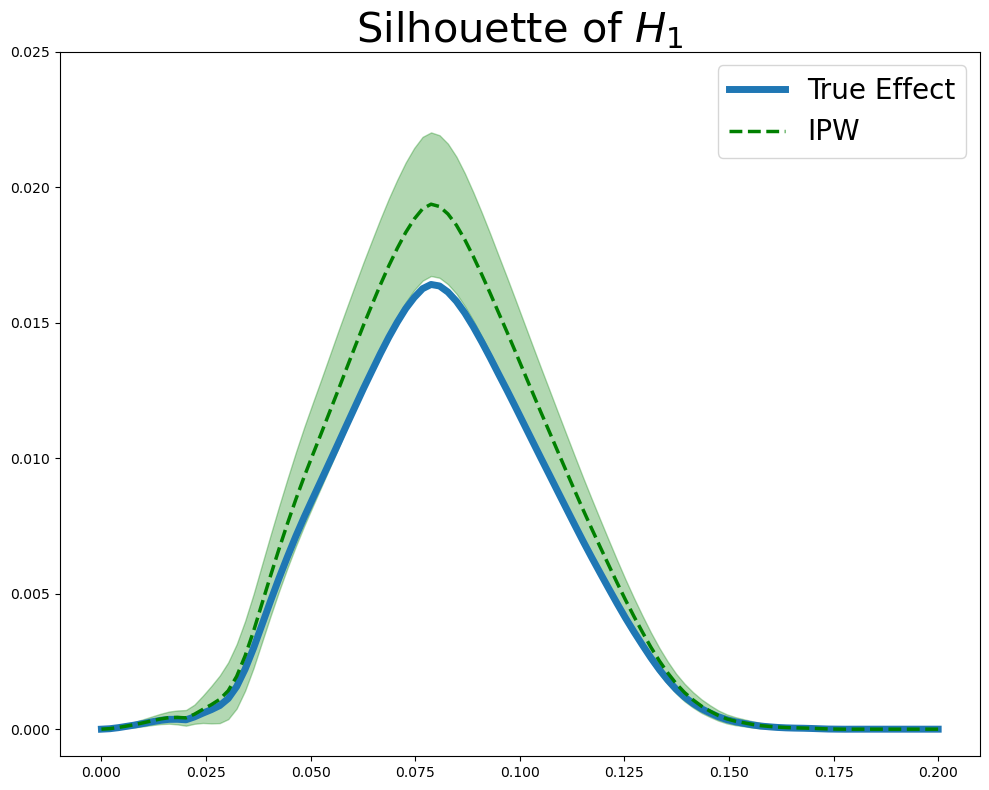

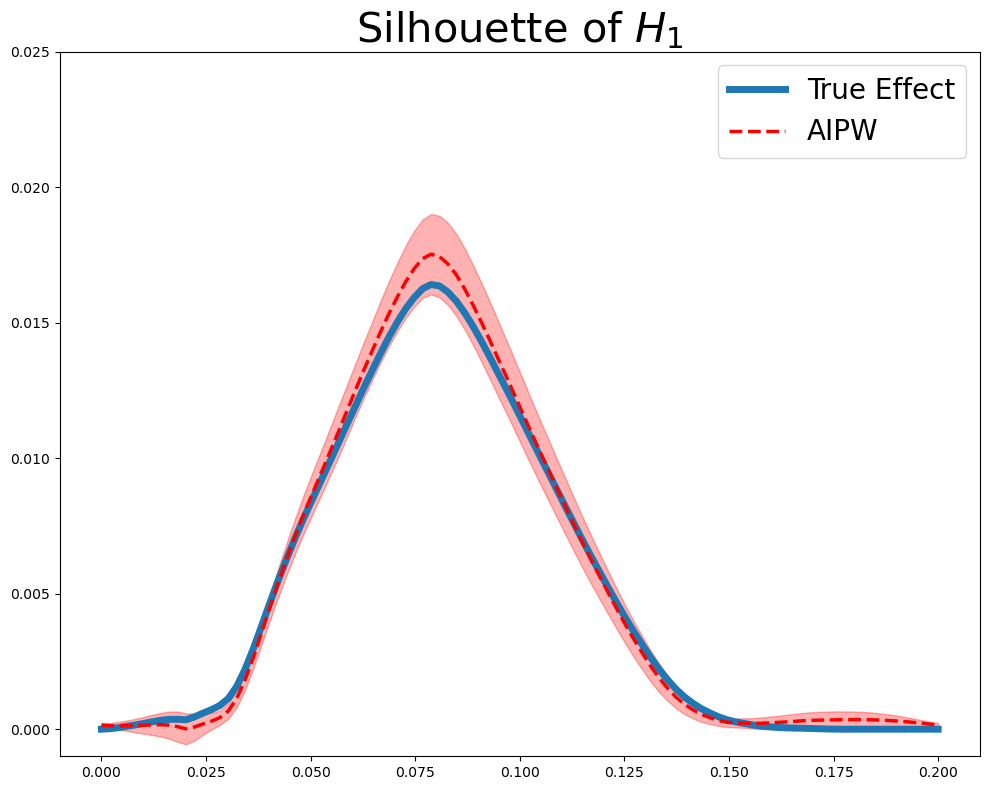

In [30]:
# # H0
# # plugin
# plt.figure(figsize=(10,8))
# plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
# plt.plot(tseq, pi0_avg, label="Plug-in", ls="--", lw=lw, c="darkorange")
# plt.fill_between(tseq, pi0_avg - pi0_std, pi0_avg + pi0_std, alpha=0.3, color="darkorange")
# plt.ylim(-0.001, 0.025)
# plt.legend(prop={"size":20})
# plt.title("Silhouette of $H_0$", size=30)
# plt.tight_layout()
# plt.show();

# # ipw
# plt.figure(figsize=(10,8))
# plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
# plt.plot(tseq, ipw0_avg, label="IPW", ls="--", lw=lw, c="green")
# plt.fill_between(tseq, ipw0_avg - ipw0_std, ipw0_avg + ipw0_std, alpha=0.3, color="green")
# plt.ylim(-0.001, 0.025)
# plt.legend(prop={"size":20})
# plt.title("Silhouette of $H_0$", size=30)
# plt.tight_layout()
# plt.show();

# # aipw
# plt.figure(figsize=(10,8))
# plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
# plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw, c="red")
# plt.fill_between(tseq, aipw0_avg - aipw0_std, aipw0_avg + aipw0_std, alpha=0.3, color="red")
# plt.ylim(-0.001, 0.025)
# plt.legend(prop={"size":20})
# plt.title("Silhouette of $H_0$", size=30)
# plt.tight_layout()
# plt.show();


# H1
# plugin
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="Plug-in", ls="--", lw=lw, c="darkorange")
plt.fill_between(tseq, pi1_avg - pi1_std, pi1_avg + pi1_std, alpha=0.3, color="darkorange")
plt.ylim(-0.001, 0.025)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

# ipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls="--", lw=lw, c="green")
plt.fill_between(tseq, ipw1_avg - ipw1_std, ipw1_avg + ipw1_std, alpha=0.3, color="green")
plt.ylim(-0.001, 0.025)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

# aipw
plt.figure(figsize=(10,8))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw, c="red")
plt.fill_between(tseq, aipw1_avg - aipw1_std, aipw1_avg + aipw1_std, alpha=0.3, color="red")
plt.ylim(-0.001, 0.025)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

# Hypothesis testing

In [31]:
def ipw_estimator2(pi_hat, sample, return_inv_weight=False):
    """_summary_

    Args:
        pi_hat (np.array of shape (n,)): Estimated propensity score.
        sample (tuple or list): Sample used for estimation. Triplet of (phi, A, X).
            - phi: Collection of silhouette functions. Shape: [n, n_hom_dim, resolution].
            - A: Treatment. Shape: [n,].
            - X: Covariates of dimension d. Shape: [n, d].
        return_inv_weight (bool, optional): Wheter to return inverse weight values. Defaults to False.

    Returns:
        (list): List containing "n_hom_dim" IPW estimates of shape [resolution, ].
    """
    phi, A, _ = sample
    n_hom_dim = phi.shape[-2]   # number of homology dimensions
    
    # avoid 0 or 1 estimated propensity score
    pi_hat[pi_hat == 0] = 1e-2   
    pi_hat[pi_hat == 1] = 1-1e-2

    # construct ipw estimator on estimation sample
    inv_weight = (A/pi_hat - (1-A)/(1-pi_hat))[:, np.newaxis]   # shape: [n, 1] 
    
    ipw = []
    for hom_dim in range(n_hom_dim):
        ipw.append(inv_weight * phi[:, hom_dim, :]) # shape [n, res]
    
    if return_inv_weight:
        return ipw, inv_weight
    return ipw

def plugin_estimator2(mu_hats, return_mu=False):
    """_summary_

    Args:
        mu_hats (list of length "n_hom_dim"): Each element is a tuple (predicted mu_hat0, predicted mu_hat1).
        return_mu (bool, optional): Wheter to return regression function values. Defaults to False.

    Returns:
        (list): List containing "n_hom_dim" plug-in estimates of shape [resolution, ].
    """    
    plugin = [mu1 - mu0 for mu0, mu1 in mu_hats]     # shape [n, res]

    if return_mu:
        mu0_list, mu1_list = zip(*mu_hats)
        return plugin, mu0_list, mu1_list
    return plugin

def aipw_estimator2(pi_hat, mu_hats, sample):
    """_summary_

    Args:
        pi_hat (np.array of shape (n,)): Estimated propensity score.
        mu_hats (list of length "n_hom_dim"): Each element is a tuple (predicted mu_hat0, predicted mu_hat1).
        sample (tuple or list): Sample used for estimation. Triplet of (phi, A, X).
            - phi_est: Collection of silhouette functions. Shape: [n, n_hom_dim, resolution].
            - A_est: Treatment. Shape: [n,].
            - X_est: Covariates of dimension d. Shape: [n, d].
    
    Returns:
        (list): List containing "n_hom_dim" doubly robust estimates of shape [resolution, ].
    """
    phi, A, _ = sample
    n_hom_dim = phi.shape[-2]       # number of homology dimensions

    ipw, inv_weight = ipw_estimator2(pi_hat, sample, return_inv_weight=True)
    plugin, mu0_list, mu1_list = plugin_estimator2(mu_hats, return_mu=True)

    dr =[]
    A = A[:, np.newaxis]
    for hom_dim in range(n_hom_dim):
        correction = ipw[hom_dim] - inv_weight*(A*mu1_list[hom_dim] + (1-A)*mu0_list[hom_dim])
        dr.append(plugin[hom_dim] + correction)
    return dr

In [32]:
np.random.seed(42)
phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
sample1 = (phi1, A1, X1)
sample2 = (phi2, A2, X2)
n_basis = 3

# fit on sample 1, estimate on sample 2
reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
pi_hat1 = RandomForestClassifier().fit(X1, A1).predict_proba(X2)[:,1]
aipw10, aipw11 = aipw_estimator2(pi_hat1, mu_hats1, sample2)

# fit on sample 2, estimate on sample 1
reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
pi_hat2 = RandomForestClassifier().fit(X2, A2).predict_proba(X1)[:,1]
aipw20, aipw21 = aipw_estimator2(pi_hat2, mu_hats2, sample1)

# average
aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
aipw1 = (aipw11 + aipw21) / 2     # homology dim 1

Tn0 = np.abs(np.mean(aipw0, axis=0)).max() * np.sqrt(500)
Tn1 = np.abs(np.mean(aipw1, axis=0)).max() * np.sqrt(500)
print(Tn0, Tn1)

0.003743045233511903 0.42415645845164945


In [33]:
np.random.seed(42)
iterations = 1000

# H0
h0_list = []
for i in range(iterations):
    multiplier = np.random.standard_normal((500, 1))
    g_hat = np.sum(multiplier * aipw0, axis=0) / np.sqrt(500)
    h0_list.append(np.abs(g_hat).max())

h0_threshold = np.quantile(np.array(h0_list), 0.95)    # 95% quantile

print(Tn0 > h0_threshold, "Tn0:", Tn0, "Threshold:", h0_threshold)


# H1
h1_list = []
for i in range(iterations):
    multiplier = np.random.standard_normal((500, 1))
    g_hat = np.sum(multiplier * aipw1, axis=0) / np.sqrt(500)
    h1_list.append(np.abs(g_hat).max())

h1_threshold = np.quantile(np.array(h1_list), 0.95)    # 95% quantile

print(Tn1 > h1_threshold, "Tn1:", Tn1, "Threshold:", h1_threshold)

False Tn0: 0.003743045233511903 Threshold: 0.027697632900648136
True Tn1: 0.42415645845164945 Threshold: 0.11071832013957991


# Estimation under Model Misspecification

## Misspecification of $\pi$

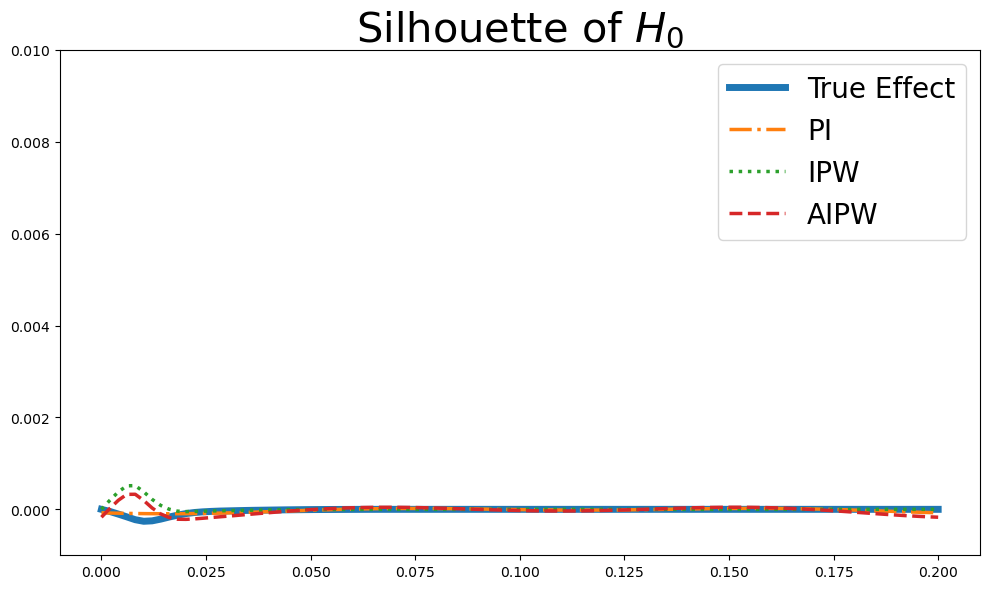

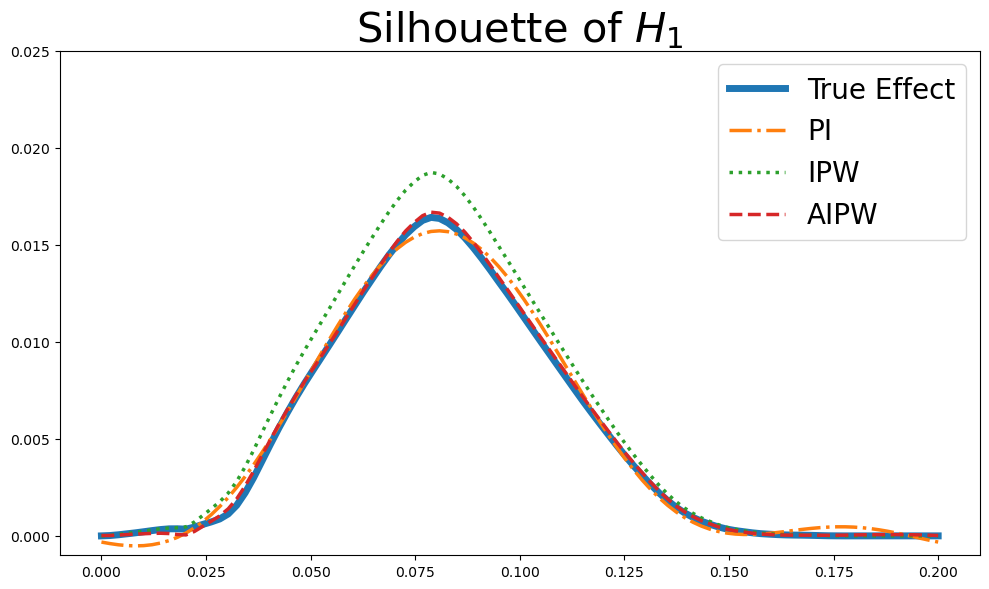

In [34]:
np.random.seed(42)

n_iter = 20
n_basis = 5

ipw0_list, plugin0_list, aipw0_list = [], [], []
ipw1_list, plugin1_list, aipw1_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n) # generate covariates
    _, A = gen_trt_prob(covariate, beta)                # generate treatment
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin10, plugin11 = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin20, plugin21 = plugin_estimator(mu_hats2)
    plugin0 = (plugin10 + plugin20) / 2  # homology dim 0
    plugin0_list.append(plugin0)
    plugin1 = (plugin11 + plugin21) / 2  # homology dim 1
    plugin1_list.append(plugin1)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = LogisticRegression(fit_intercept=False, penalty=None).fit(X1[:, [0, 2]], A1).predict_proba(X2[:, [0, 2]])[:,1]
    ipw10, ipw11 = ipw_estimator(pi_hat1, sample2)
    # fit on sample 2, estimate on sample 1
    pi_hat2 = LogisticRegression(fit_intercept=False, penalty=None).fit(X2[:, [0, 2]], A2).predict_proba(X1[:, [0, 2]])[:,1]
    ipw20, ipw21 = ipw_estimator(pi_hat2, sample1)
    ipw0 = (ipw10 + ipw20) / 2  # homology dim 0
    ipw0_list.append(ipw0)
    ipw1 = (ipw11 + ipw21) / 2  # homology dim 1
    ipw1_list.append(ipw1)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw10, aipw11 = aipw_estimator(pi_hat1, mu_hats1, sample2)
    # fit on sample 2, estimate on sample 1
    aipw20, aipw21 = aipw_estimator(pi_hat2, mu_hats2, sample1)
    aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
    aipw0_list.append(aipw0)
    aipw1 = (aipw11 + aipw21) / 2     # homology dim 1
    aipw1_list.append(aipw1)


# plot H0
ipw0_avg = np.mean(ipw0_list, axis=0)
ipw0_std = np.std(ipw0_list, axis=0)
pi0_avg = np.mean(plugin0_list, axis=0)
pi0_std = np.std(plugin0_list, axis=0)
aipw0_avg = np.mean(aipw0_list, axis=0)
aipw0_std = np.std(aipw0_list, axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.001, 0.01)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# plot H1
ipw1_avg = np.mean(ipw1_list, axis=0)
ipw1_std = np.std(ipw1_list, axis=0)
pi1_avg = np.mean(plugin1_list, axis=0)
pi1_std = np.std(plugin1_list, axis=0)
aipw1_avg = np.mean(aipw1_list, axis=0)
aipw1_std = np.std(aipw1_list, axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.001, 0.025)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

### $L_1$ distance and Std.

In [35]:
# H0
# L1 distance between true effect and average estimated effect
l1_pi0 = numerical_integration(np.abs(true_effect[0] - pi0_avg), tseq)
l1_ipw0 = numerical_integration(np.abs(true_effect[0] - ipw0_avg), tseq)
l1_aipw0 = numerical_integration(np.abs(true_effect[0] - aipw0_avg), tseq)

print(f"H0 L1 dist: PI:{l1_pi0} IPW:{l1_ipw0} AIPW:{l1_aipw0}")

# covariance
cov_pi0 = np.cov(np.array(plugin0_list), rowvar=False)
cov_ipw0 = np.cov(np.array(ipw0_list), rowvar=False)
cov_aipw0 = np.cov(np.array(aipw0_list), rowvar=False)

print(f"H0 Std.: PI:{np.sqrt(cov_pi0.mean())} IPW:{np.sqrt(cov_ipw0.mean())} AIPW:{np.sqrt(cov_aipw0.mean())}")

# H1
# L1 distance between true effect and average estimated effect
l1_pi1 = numerical_integration(np.abs(true_effect[1] - pi1_avg), tseq)
l1_ipw1 = numerical_integration(np.abs(true_effect[1] - ipw1_avg), tseq)
l1_aipw1 = numerical_integration(np.abs(true_effect[1] - aipw1_avg), tseq)

print(f"H1 L1 dist: PI:{l1_pi1} IPW:{l1_ipw1} AIPW:{l1_aipw1}")

# covariance
cov_pi1 = np.cov(np.array(plugin1_list), rowvar=False)
cov_ipw1 = np.cov(np.array(ipw1_list), rowvar=False)
cov_aipw1 = np.cov(np.array(aipw1_list), rowvar=False)

print(f"H1 Std.: PI:{np.sqrt(cov_pi1.mean())} IPW:{np.sqrt(cov_ipw1.mean())} AIPW:{np.sqrt(cov_aipw1.mean())}")

H0 L1 dist: PI:5.136672311379727e-06 IPW:7.957254154145502e-06 AIPW:1.3470528697133988e-05
H0 Std.: PI:6.879877258100788e-06 IPW:2.2996775787646022e-05 AIPW:6.807814315464073e-06
H1 L1 dist: PI:7.2982256340841e-05 IPW:0.00017575553301665586 AIPW:2.6048391044881137e-05
H1 Std.: PI:0.0003717863715215399 IPW:0.00045286911325846397 AIPW:0.0003958212392338098


## Misspecification of $\mu$

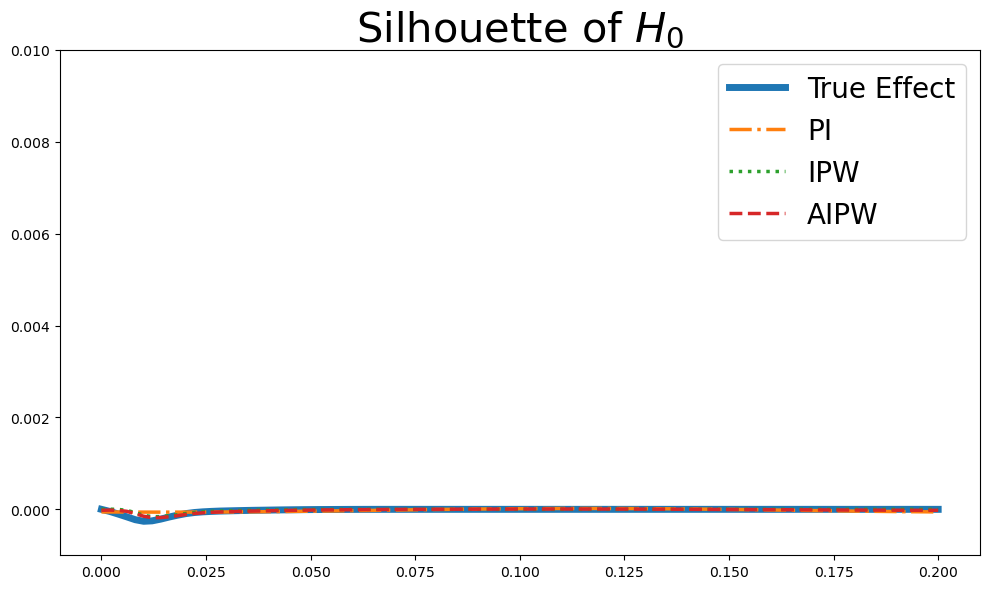

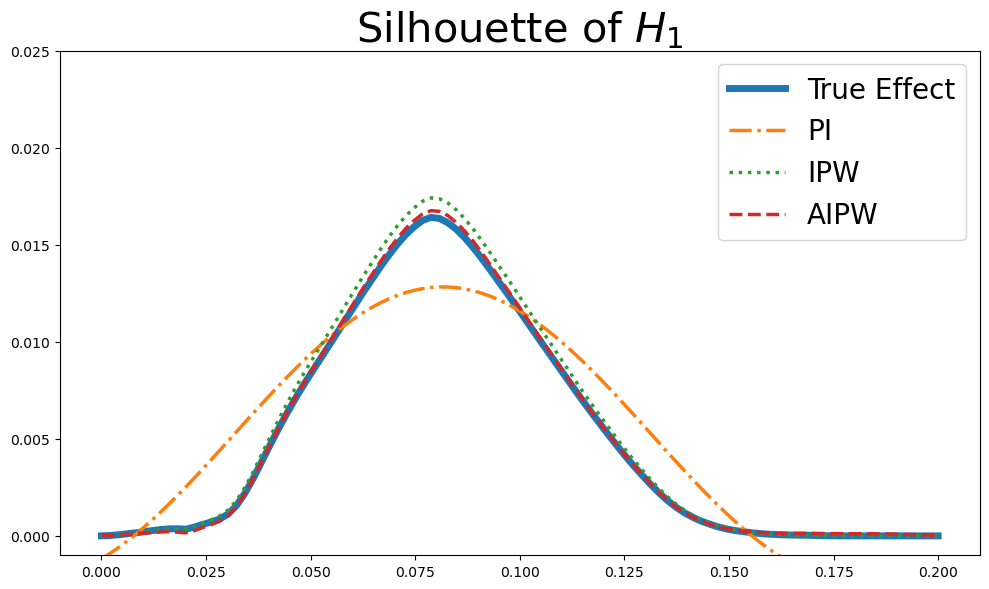

In [36]:
np.random.seed(42)

n_iter = 20
n_basis = 2

ipw0_list, plugin0_list, aipw0_list = [], [], []
ipw1_list, plugin1_list, aipw1_list = [], [], []

for i in range(n_iter):
    _, _, covariate = gen_covariate(mu1, mu2, Sigma, n) # generate covariates
    _, A = gen_trt_prob(covariate, beta)                # generate treatment
    observed_data = (potential_outcomes[range(n), A], A, covariate) # construct observed data

    # sample split
    phi1, phi2, A1, A2, X1, X2 = train_test_split(*observed_data, test_size=0.5, random_state=0, stratify=observed_data[1])   # stratify on A
    sample1 = (phi1, A1, X1)
    sample2 = (phi2, A2, X2)

    # plug-in
    # fit on sample 1, estimate on sample 2
    reg1 = fit_functional_regression(sample1, tseq, n_basis=n_basis)
    mu_hats1= [(mu0.predict(pd.DataFrame(X2))(tseq).squeeze(), mu1.predict(pd.DataFrame(X2))(tseq).squeeze()) for mu0, mu1 in reg1]
    plugin10, plugin11 = plugin_estimator(mu_hats1)
    # fit on sample 2, estimate on sample 1
    reg2 = fit_functional_regression(sample2, tseq, n_basis=n_basis)
    mu_hats2 = [(mu0.predict(pd.DataFrame(X1))(tseq).squeeze(), mu1.predict(pd.DataFrame(X1))(tseq).squeeze()) for mu0, mu1 in reg2]
    plugin20, plugin21 = plugin_estimator(mu_hats2)
    plugin0 = (plugin10 + plugin20) / 2  # homology dim 0
    plugin0_list.append(plugin0)
    plugin1 = (plugin11 + plugin21) / 2  # homology dim 1
    plugin1_list.append(plugin1)

    # ipw
    # fit on sample 1, estimate on sample 2
    pi_hat1 = LogisticRegression(fit_intercept=False, penalty=None).fit(np.hstack([X1, X1[:,[1]]*X1[:,[2]], X1[:,[0]]*X1[:,[2]]]), A1).predict_proba(np.hstack([X2, X2[:,[1]]*X2[:,[2]], X2[:,[0]]*X2[:,[2]]]))[:,1]
    ipw10, ipw11 = ipw_estimator(pi_hat1, sample2)
    # fit on sample 2, estimate on sample 1
    pi_hat2 = LogisticRegression(fit_intercept=False, penalty=None).fit(np.hstack([X2, X2[:,[1]]*X2[:,[2]], X2[:,[0]]*X2[:,[2]]]), A2).predict_proba(np.hstack([X1, X1[:,[1]]*X1[:,[2]], X1[:,[0]]*X1[:,[2]]]))[:,1]
    ipw20, ipw21 = ipw_estimator(pi_hat2, sample1)
    ipw0 = (ipw10 + ipw20) / 2  # homology dim 0
    ipw0_list.append(ipw0)
    ipw1 = (ipw11 + ipw21) / 2  # homology dim 1
    ipw1_list.append(ipw1)

    # aipw
    # fit on sample 1, estimate on sample 2
    aipw10, aipw11 = aipw_estimator(pi_hat1, mu_hats1, sample2)
    # fit on sample 2, estimate on sample 1
    aipw20, aipw21 = aipw_estimator(pi_hat2, mu_hats2, sample1)
    aipw0 = (aipw10 + aipw20) / 2     # homology dim 0
    aipw0_list.append(aipw0)
    aipw1 = (aipw11 + aipw21) / 2     # homology dim 1
    aipw1_list.append(aipw1)


# plot H0
ipw0_avg = np.mean(ipw0_list, axis=0)
ipw0_std = np.std(ipw0_list, axis=0)
pi0_avg = np.mean(plugin0_list, axis=0)
pi0_std = np.std(plugin0_list, axis=0)
aipw0_avg = np.mean(aipw0_list, axis=0)
aipw0_std = np.std(aipw0_list, axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[0], label="True Effect", lw=2*lw)
plt.plot(tseq, pi0_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw0_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw0_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.001, 0.01)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_0$", size=30)
plt.tight_layout()
plt.show();

# plot H1
ipw1_avg = np.mean(ipw1_list, axis=0)
ipw1_std = np.std(ipw1_list, axis=0)
pi1_avg = np.mean(plugin1_list, axis=0)
pi1_std = np.std(plugin1_list, axis=0)
aipw1_avg = np.mean(aipw1_list, axis=0)
aipw1_std = np.std(aipw1_list, axis=0)

plt.figure(figsize=(10,6))
plt.plot(tseq, true_effect[1], label="True Effect", lw=2*lw)
plt.plot(tseq, pi1_avg, label="PI", ls="-.", lw=lw)
plt.plot(tseq, ipw1_avg, label="IPW", ls=":", lw=lw)
plt.plot(tseq, aipw1_avg, label="AIPW", ls="--", lw=lw)
plt.ylim(-0.001, 0.025)
plt.legend(prop={"size":20})
plt.title("Silhouette of $H_1$", size=30)
plt.tight_layout()
plt.show();

### $L_1$ distance and Std.

In [37]:
# H0
# L1 distance between true effect and average estimated effect
l1_pi0 = numerical_integration(np.abs(true_effect[0] - pi0_avg), tseq)
l1_ipw0 = numerical_integration(np.abs(true_effect[0] - ipw0_avg), tseq)
l1_aipw0 = numerical_integration(np.abs(true_effect[0] - aipw0_avg), tseq)

print(f"H0 L1 dist: PI:{l1_pi0} IPW:{l1_ipw0} AIPW:{l1_aipw0}")

# covariance
cov_pi0 = np.cov(np.array(plugin0_list), rowvar=False)
cov_ipw0 = np.cov(np.array(ipw0_list), rowvar=False)
cov_aipw0 = np.cov(np.array(aipw0_list), rowvar=False)

print(f"H0 Std.: PI:{np.sqrt(cov_pi0.mean())} IPW:{np.sqrt(cov_ipw0.mean())} AIPW:{np.sqrt(cov_aipw0.mean())}")

# H1
# L1 distance between true effect and average estimated effect
l1_pi1 = numerical_integration(np.abs(true_effect[1] - pi1_avg), tseq)
l1_ipw1 = numerical_integration(np.abs(true_effect[1] - ipw1_avg), tseq)
l1_aipw1 = numerical_integration(np.abs(true_effect[1] - aipw1_avg), tseq)

print(f"H1 L1 dist: PI:{l1_pi1} IPW:{l1_ipw1} AIPW:{l1_aipw1}")

# covariance
cov_pi1 = np.cov(np.array(plugin1_list), rowvar=False)
cov_ipw1 = np.cov(np.array(ipw1_list), rowvar=False)
cov_aipw1 = np.cov(np.array(aipw1_list), rowvar=False)

print(f"H1 Std.: PI:{np.sqrt(cov_pi1.mean())} IPW:{np.sqrt(cov_ipw1.mean())} AIPW:{np.sqrt(cov_aipw1.mean())}")

H0 L1 dist: PI:5.997450209242274e-06 IPW:1.563760087418886e-06 AIPW:2.8382968274581915e-06
H0 Std.: PI:6.879877258100805e-06 IPW:1.481764720523999e-05 AIPW:7.478111138906447e-06
H1 L1 dist: PI:0.00036322574150826197 IPW:7.092221360825167e-05 AIPW:2.3535214072921476e-05
H1 Std.: PI:0.00037178637152154035 IPW:0.0005576253087310687 AIPW:0.00040813474192516745
